In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ember-2017-v2-features/ember-2017-v2f-fastai-tl-0.988-auroc.ipynb

/kaggle/input/ember-2017-v2-features/train_ember_2017_v2_features.parquet

/kaggle/input/ember-2017-v2-features/test_ember_2017_v2_features.parquet

/kaggle/input/ember-2018-v2-features/train_ember_2018_v2_features.parquet

/kaggle/input/ember-2018-v2-features/ember-2018-v2f-fastai-tl-0.-auroc.ipynb

/kaggle/input/ember-2018-v2-features/test_ember_2018_v2_features.parquet


In [2]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score, RocCurveDisplay
from fastai.tabular.all import *

In [3]:
df_train = pd.read_parquet('/kaggle/input/ember-2018-v2-features/train_ember_2018_v2_features.parquet')
df_test = pd.read_parquet('/kaggle/input/ember-2018-v2-features/test_ember_2018_v2_features.parquet')

In [4]:
df_train = df_train[df_train['Label'].isin([0,1])]

In [5]:
train_samples = df_train.shape[0]
test_samples = df_test.shape[0]
train_samples, test_samples

(599920, 199956)

In [6]:
target = 'Label'

In [7]:
df = pd.concat(objs=[df_train, df_test], axis=0, copy=True, sort=False, ignore_index=True)
df.shape

(799876, 2382)

In [8]:
import gc
del [[df_train, df_test]]
gc.collect()
df_train = pd.DataFrame()
df_test = pd.DataFrame()

In [9]:
conts, cats = cont_cat_split(df, dep_var=target)
len(conts), len(cats)

(2381, 0)

In [10]:
df = TabularPandas(
    df=df, 
    procs=[Normalize],
    cat_names=cats,
    cont_names=conts,
    y_block=CategoryBlock,
    y_names=target,
    splits = IndexSplitter(valid_idx=range(train_samples, train_samples+test_samples))(range_of(df)),
    reduce_memory=True,
)

In [11]:
df

              F1        F2        F3        F4        F5        F6        F7  \
0      -1.093639 -0.620841 -0.432635 -0.238727 -0.338658 -0.070794 -0.154917   
1      -0.153560  1.683004 -0.196115  0.011472  0.005523 -0.119379  0.119899   
2       0.218454  0.228264 -0.042633  0.348246  1.282681 -0.240048 -0.214290   
3      -1.125253 -0.635059 -0.432358 -0.250793 -0.336206 -0.051862 -0.151900   
4      -1.061952 -0.536523 -0.352963 -0.229895 -0.319294 -0.023891 -0.160542   
...          ...       ...       ...       ...       ...       ...       ...   
799871 -0.016898 -0.391282 -0.335534 -0.149366 -0.126037 -0.076816 -0.235924   
799872  0.086353  0.233653  0.006794  0.357387  0.506824  0.155503 -0.164343   
799873 -0.273481 -0.350201 -0.556679 -0.339774  0.181473  0.276342 -0.526431   
799874  0.113769  0.836782  0.452980  0.656907  0.216510  0.478954  1.292499   
799875  1.561618 -0.622129 -0.681748 -0.488359 -0.457061 -0.273858 -0.370920   

              F8        F9       F10  .

In [12]:
len(df.train), len(df.valid)

(599920, 199956)

In [13]:
dls = df.dataloaders(bs=64)

## Fast.ai TabularLearner results

In [14]:
roc_auc_binary = RocAucBinary()
tl = tabular_learner(dls, metrics=[roc_auc_binary])

In [15]:
cbs = [
    TrackerCallback(monitor='valid_loss', comp=None, min_delta=0.0, reset_on_fit=True),
    EarlyStoppingCallback(monitor='valid_loss', comp=None, min_delta=0.0, patience=1, reset_on_fit=True)
]

tl.fit_one_cycle(10, cbs=cbs) # learning rate scheduling: docs.fast.ai/callback.schedule.html#learner.fit_one_cycle

epoch,train_loss,valid_loss,roc_auc_score,time
0,0.143956,8.831429,0.949007,00:53
1,0.126239,14.678936,0.958209,00:52


No improvement since epoch 0: early stopping


In [16]:
preds_train, ground_truth_train = tl.get_preds(ds_idx=0, dl=None)

In [17]:
preds_train

tensor([[9.3308e-01, 6.6924e-02],
        [9.2960e-01, 7.0402e-02],
        [5.7008e-01, 4.2992e-01],
        ...,
        [9.9183e-01, 8.1685e-03],
        [8.0501e-04, 9.9920e-01],
        [3.4597e-04, 9.9965e-01]])

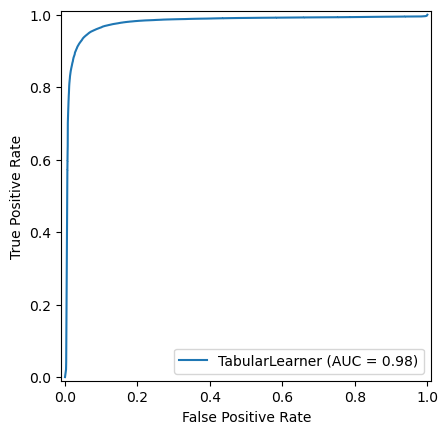

In [18]:
fpr, tpr, thresholds = roc_curve(to_np(ground_truth_train), to_np(preds_train[:,1]))
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='TabularLearner')
display.plot()

In [19]:
# Test set predictions
preds_test, ground_truth_test = tl.get_preds(ds_idx=1, dl=None) # we want the validation (test) set hence ds_idx=1

In [20]:
# transform tensor to numpy array
preds_test = to_np(preds_test[:,1]) # keep only prediction values for the positive class
ground_truth_test = to_np(ground_truth_test)

preds_test_binary = (preds_test >= best_thresh).astype(int)

print("Test predictions shape:", preds_test_binary.shape)
print("Best threshold:", best_thresh)

Test predictions shape: (199956,)

Best threshold: 0.520144


In [21]:
print("The final tabular learner results")
print("ROC-AUC:", round(roc_auc_score(y_true=ground_truth_test, y_score=preds_test), 4))  # Use probability for ROC-AUC
print("Precision:", round(precision_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))
print("Recall:", round(recall_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))
print("F1:", round(f1_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))

The final tabular learner results

ROC-AUC: 0.9582

Precision: 0.9152

Recall: 0.9188

F1: 0.917
